In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우
plt.rcParams['axes.unicode_minus'] = False

In [23]:
df = pd.read_csv('../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
# merged = pd.read_cs/v('../../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
df.head()

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,289.682121,39427.386,-0.390397,-3.492136


In [24]:
df.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '지역내총생산(십억원)',
       '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [25]:
# 변수 분류
# 종속변수
y_cols = df[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = df[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도']]

# 독립변수(통계방식변경)
x_cols_control = df[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '통계방식변경']]


# 통제변수
meta_cols = df[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = df[['연도', '행정구역']]

In [26]:
# # merged.describe()
# grouped_desc = (
#     df
#     .groupby(["연도", "행정구역"])
#     .describe()
# )
# grouped_desc

In [27]:
# 연도별 전국 평균 표준편차 계산
# y, x, 연도만 사용
tmp = pd.concat(
    [
        group_cols[['연도', '행정구역']],
        y_cols,
        x_cols,
        meta_cols
    ],
    axis=1
)
targets = list(y_cols.columns) + list(x_cols.columns) + list(meta_cols.columns)

# 연도별 전국 평균·표준편차
year_stats = (
    tmp
    .groupby('연도')[targets]
    .agg(['mean', 'std'])
)

year_stats


청년_19_29_증감률(%)           청년_30_39_증감률(%)              상용월평균급여(원)  \
                mean       std            mean       std          mean   
연도                                                                       
2016        1.745261  5.002492       -0.529242  5.411502  3.262126e+06   
2017        0.518233  2.375020       -1.387408  4.043361  3.343778e+06   
2018        0.300712  2.513648       -1.458068  3.930544  3.449791e+06   
2019        0.087444  1.786005       -2.689334  2.347697  3.554714e+06   
2020       -0.210732  2.183387       -3.446449  1.474950  3.545896e+06   
2021       -3.063753  1.183305       -2.605836  1.379074  3.706029e+06   
2022       -3.284677  3.020555       -1.972990  1.471374  3.820300e+06   
2023       -3.972541  1.514472       -1.215504  1.418953  3.927505e+06   
2024       -4.490844  1.072935       -0.022372  1.054591  4.102117e+06   

                       문화예술활동(건)               대학수(천명당)            \
                std         mean          std      mean       std   
연도                                                                  
2016  396879.424366  2018.588235  2801.708587  0.009420  0.003449   
2017  375475.993843  2189.823529  2976.013467  0.009312  0.003364   
2018  370689.473495  2347.705882  3183.839030  0.009403  0.003440   
2019  365836.537414  1877.882353  2853.129091  0.009357  0.003383   
2020  336475.780720   909.882353  1251.992406  0.009308  0.003337   
2021  361085.190085  1877.882353  2853.129091  0.009242  0.003339   
2022  354737.209220  2384.235294  3480.386500  0.009250  0.003343   
2023  372872.600611  2641.235294  3486.440046  0.009273  0.003388   
2024  414407.751534  2789.294118  3772.092850  0.009234  0.003361   

     문화기반시설수(십만명당)                  기업밀도                연앙인구수(천명)  \
              mean       std        mean         std         mean   
연도                                                                  
2016      6.732935  4.518143  563.753020  548.027848  3006.645382   
2017      6.846908  4.496901  565.187041  548.482927  3013.570824   
2018      7.082346  4.613839  562.016683  546.547750  3017.698794   
2019      7.572547  4.709427  559.513899  552.754289  3019.848441   
2020      7.700823  4.622782  742.272842  775.697001  3020.544647   
2021      7.769463  4.508270  743.919387  781.464972  3019.603088   
2022      8.027221  4.603133  741.983869  786.477663  3015.244088   
2023      8.097170  4.410678  746.485095  798.401674  3008.581441   
2024      8.131262  4.447198  752.878925  810.100629  3002.191324   

                    재정자립도(%)               지역내총생산(십억원)                 
              std       mean        std           mean            std  
연도                                                                     
2016  3224.917013  43.035294  17.360629  107933.419353  121561.758347  
2017  3243.087343  44.015294  17.157115  113871.151706  131008.085307  
2018  3264.953886  43.321765  16.939688  118106.566294  138944.358499  
2019  3291.114874  41.595882  16.649647  120175.367647  141198.981008  
2020  3319.684298  41.725294  14.810150  121322.935647  145393.583938  
2021  3345.104847  40.263529  14.863492  130834.101706  156269.028892  
2022  3357.002948  41.275294  15.002415  136917.392588  162706.905009  
2023  3361.221684  41.436471  14.622563  141874.326824  166864.761003  
2024  3367.698725  40.140000  13.841996  150635.970294  179037.378103

In [28]:
# 연도별 전국 기준 Z값 계산
tmp_z = tmp.copy()

for col in targets:
    mean = tmp_z.groupby('연도')[col].transform('mean')
    std  = tmp_z.groupby('연도')[col].transform('std')

    tmp_z[col + '_z'] = (tmp_z[col] - mean) / std

z_cols = [c + "_z" for c in targets]

In [29]:
# z값 검증_연도별 Z 평균 ≈ 0 ?
tmp_z.groupby('연도')[z_cols].mean()

,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
연도,,,,,,,,,,
2016,-6.530724e-18,1.306145e-17,4.767428e-16,2.285753e-17,1.306145e-17,3.265362e-17,-1.110223e-16,9.469549e-17,-2.481675e-16,-8.489941e-17
2017,1.469413e-17,2.612289e-17,7.436862e-16,-9.143013e-17,-8.489941e-17,0.000000e+00,-5.224579e-17,1.142877e-16,-6.530724e-17,6.204187e-17
2018,-9.796086e-18,-6.977160e-17,6.020511e-16,5.551115e-17,-7.836868e-17,-2.449021e-17,3.918434e-17,9.796086e-18,1.110223e-16,-6.204187e-17
2019,-1.142877e-17,-8.816477e-17,6.122553e-16,-1.632681e-17,-2.089832e-16,-3.755166e-17,3.265362e-18,-6.204187e-17,7.836868e-17,-2.938826e-17
2020,1.632681e-17,7.183796e-17,-8.979745e-17,-6.530724e-18,-2.808211e-16,-2.155139e-16,6.530724e-17,-1.012262e-16,-7.183796e-17,-6.530724e-18
2021,-2.742904e-16,-1.893910e-16,-5.975612e-16,-1.632681e-17,3.265362e-17,1.453086e-16,1.044916e-16,-2.938826e-17,-1.436759e-16,1.632681e-17
2022,-1.175530e-16,-8.163405e-17,5.338867e-16,6.857260e-17,-2.155139e-16,1.191857e-16,5.224579e-17,9.143013e-17,9.796086e-17,-1.959217e-17
2023,2.089832e-16,1.306145e-17,5.126618e-16,4.244970e-17,7.183796e-17,1.763295e-16,-5.877651e-17,1.306145e-17,-2.612289e-17,-2.285753e-17
2024,-3.722512e-16,-1.306145e-17,1.959217e-16,-3.265362e-17,1.240837e-16,-1.518393e-16,-2.285753e-17,-6.857260e-17,0.000000e+00,-6.857260e-17


In [30]:
# z값 검증: 연도별 Z 표준편차 ≈ 1 ?
tmp_z.groupby('연도')[z_cols].std()

,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
연도,,,,,,,,,,
2016,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2017,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2020,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2021,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2022,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [31]:
# # 검증
# targets = list(y_cols.columns) + list(x_cols.columns)
# # z_cols = [c + "_z" for c in targets]
# tmp_z.groupby('연도')[z_cols].mean() # 0 근처면 정상

In [32]:
tmp_z['행정구역']

0      강원특별자치도
1          경기도
2         경상남도
3         경상북도
4        광주광역시
        ...   
148       전라남도
149    전북특별자치도
150    제주특별자치도
151       충청남도
152       충청북도
Name: 행정구역, Length: 153, dtype: object

In [33]:
tmp_z[['행정구역', '연도']]

,행정구역,연도
0,강원특별자치도,2016
1,경기도,2016
2,경상남도,2016
3,경상북도,2016
4,광주광역시,2016
...,...,...
148,전라남도,2024
149,전북특별자치도,2024
150,제주특별자치도,2024
151,충청남도,2024


In [34]:
z_cols_all = tmp_z[['행정구역', '연도'] + z_cols]
z_cols_all

,행정구역,연도,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
0,강원특별자치도,2016,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361
1,경기도,2016,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738
2,경상남도,2016,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773
3,경상북도,2016,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230
4,광주광역시,2016,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549
...,...,...,...,...,...,...,...,...,...,...,...,...
148,전라남도,2024,-0.518022,0.005958,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644
149,전북특별자치도,2024,-0.972103,-0.271329,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302
150,제주특별자치도,2024,-0.976313,-0.769400,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959
151,충청남도,2024,1.911852,0.311186,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253


In [35]:
# 부산 Z값 구하기
z_cols_busan = tmp_z[tmp_z['행정구역'] == '부산광역시'][['연도'] + z_cols]
z_cols_busan

,연도,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
7,2016,-0.579380,-0.239824,-0.752048,0.203951,-0.724384,-0.871036,0.244947,0.142879,0.453596,-0.127948
24,2017,-0.522525,-0.426332,-0.743358,0.186550,-0.697547,-0.857878,0.233573,0.133287,0.516095,-0.157955
41,2018,-0.655244,-0.457192,-0.616407,0.145828,-0.692370,-0.856537,0.224377,0.122626,0.532964,-0.155544
58,2019,-0.881924,-0.507070,-0.654720,-0.007670,-0.673343,-0.831291,0.202989,0.112518,0.505363,-0.146210
75,2020,-0.749982,-0.193108,-0.485619,0.074376,-0.653049,-0.824099,0.178028,0.104236,0.502001,-0.158862
92,2021,-0.148821,-0.278071,-0.394760,-0.007670,-0.707601,-0.801185,0.159529,0.096783,0.389980,-0.155654
109,2022,-0.658018,-0.026412,-0.511767,0.155662,-0.692672,-0.807214,0.143142,0.089801,0.374920,-0.141809
126,2023,-0.402256,-0.102928,-0.416512,0.116384,-0.674306,-0.843869,0.128063,0.084120,0.309353,-0.152871
143,2024,-0.924423,-0.657936,-0.473356,0.078923,-0.561149,-0.836980,0.108004,0.078339,0.360497,-0.165156


In [36]:
# 부산 z값 기술통계값 
z_cols_busan.describe()

,연도,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,2020.000000,-0.613619,-0.320986,-0.560950,0.105148,-0.675158,-0.836676,0.180295,0.107177,0.438308,-0.151334
std,2.738613,0.240070,0.205219,0.135050,0.077307,0.047528,0.023429,0.049050,0.022376,0.081267,0.011148
min,2016.000000,-0.924423,-0.657936,-0.752048,-0.007670,-0.724384,-0.871036,0.108004,0.078339,0.309353,-0.165156
25%,2018.000000,-0.749982,-0.457192,-0.654720,0.074376,-0.697547,-0.856537,0.143142,0.089801,0.374920,-0.157955
50%,2020.000000,-0.655244,-0.278071,-0.511767,0.116384,-0.692370,-0.836980,0.178028,0.104236,0.453596,-0.155544
75%,2022.000000,-0.522525,-0.193108,-0.473356,0.155662,-0.673343,-0.824099,0.224377,0.122626,0.505363,-0.146210
max,2024.000000,-0.148821,-0.026412,-0.394760,0.203951,-0.561149,-0.801185,0.244947,0.142879,0.532964,-0.127948


In [37]:
# z_cols_busan['평균'] = z_cols_busan.sum(axis=1)

In [38]:
# tmp_z.groupby('행정구역')[z_cols].mean()

In [39]:
# 행정구역별 Z분포 요약(위험도 비교) - 30대 
tmp_z.groupby('행정구역')['청년_30_39_증감률(%)_z'].describe()

,count,mean,std,min,25%,50%,75%,max
행정구역,,,,,,,,
강원특별자치도,9.0,0.108228,0.372285,-0.353001,-0.275186,0.090351,0.444217,0.631779
경기도,9.0,0.796413,0.576498,-0.045046,0.433617,0.778997,1.151131,1.662441
경상남도,9.0,-1.066405,0.693290,-1.813716,-1.701575,-1.428222,-0.366213,-0.211247
경상북도,9.0,-0.860160,0.501164,-1.525823,-1.347170,-0.802525,-0.397638,-0.304519
광주광역시,9.0,-0.430777,0.258199,-0.705553,-0.547518,-0.520556,-0.487049,0.123046
대구광역시,9.0,-0.055003,0.470962,-0.420225,-0.377181,-0.260962,0.112126,0.884987
대전광역시,9.0,0.086394,0.619343,-0.527579,-0.440297,-0.055763,0.612449,1.170668
부산광역시,9.0,-0.320986,0.205219,-0.657936,-0.457192,-0.278071,-0.193108,-0.026412
서울특별시,9.0,0.322910,0.582264,-0.431266,-0.246412,0.280829,0.791670,1.058663


In [40]:
# 행정구역별 Z분포 요약(위험도 비교) - 20대 
tmp_z.groupby('행정구역')['청년_19_29_증감률(%)_z'].describe()

,count,mean,std,min,25%,50%,75%,max
행정구역,,,,,,,,
강원특별자치도,9.0,-0.222406,0.455490,-0.769281,-0.516152,-0.450210,0.206627,0.430523
경기도,9.0,0.636098,0.563275,-0.098518,0.246560,0.615856,0.930361,1.477147
경상남도,9.0,-0.755761,0.455449,-1.537010,-0.984428,-0.791847,-0.359782,-0.133222
경상북도,9.0,-0.633514,0.429613,-1.253624,-0.855252,-0.747594,-0.401199,0.255361
광주광역시,9.0,0.066078,0.855944,-0.669863,-0.586997,-0.114938,0.158246,1.984040
대구광역시,9.0,-0.453643,0.238310,-0.976568,-0.553662,-0.344089,-0.321148,-0.201089
대전광역시,9.0,0.178395,0.538274,-0.517939,-0.220938,-0.013189,0.654250,1.000479
부산광역시,9.0,-0.613619,0.240070,-0.924423,-0.749982,-0.655244,-0.522525,-0.148821
서울특별시,9.0,0.221837,0.521984,-0.528923,-0.151338,0.192093,0.426651,1.087670


In [41]:
# # 연도별 박스플롯(전국분포) + 부산 점
# import numpy as np
# import matplotlib.pyplot as plt

# def boxplot_yearly_with_busan_point(
#     df_z,
#     z_col,
#     *,
#     year_col="연도",
#     region_col="행정구역",
#     busan_name="부산광역시",
#     title=None
# ):
#     # 1) 연도 정렬
#     years = sorted(df_z[year_col].dropna().unique())

#     # 2) 연도별 전국 Z 분포(박스플롯용 리스트)
#     data_by_year = []
#     busan_points = []

#     for y in years:
#         df_y = df_z[df_z[year_col] == y]

#         # 2-1) 전국 분포
#         vals = df_y[z_col].dropna().astype(float).values
#         data_by_year.append(vals)

#         # 2-2) 부산 값(점)
#         b = df_y[df_y[region_col] == busan_name][z_col]
#         busan_points.append(float(b.iloc[0]) if len(b) else np.nan)

#     # 3) 그림
#     plt.figure(figsize=(12, 5))
#     ax = plt.gca()

#     # 박스플롯 (전국 분포)
#     ax.boxplot(
#         data_by_year,
#         labels=years,
#         showfliers=False  # 이상치 점 숨김(원하면 True)
#     )

#     # 부산 점 오버레이
#     x = np.arange(1, len(years) + 1)
#     ax.scatter(x, busan_points, s=50, marker="o", label="부산")

#     # 기준선(전국 평균=0선)
#     ax.axhline(0, linestyle="--", linewidth=1)

#     ax.set_ylabel("Z-score (전국 대비 상대 위치)")
#     ax.set_title(title if title else f"[연도별 박스플롯 + 부산 점] {z_col}")
#     ax.legend()

#     plt.xticks(rotation=0)
#     plt.tight_layout()
#     plt.show()


In [42]:
# try:
#     print("HERE")
#     boxplot_yearly_with_busan_point(
#         df_z=tmp_z,
#         z_col="청년_19_29_증감률(%)_z",
#         title="전국대비 상대 증감률(Z) - 19~29"
#     )
#     print("DONE")
# except Exception as e:
#     import traceback
#     traceback.print_exc()


In [43]:
# print("HERE")
# boxplot_yearly_with_busan_point(
#     df_z=tmp_z,
#     z_col="청년_19_29_증감률(%)_z",
#     title="전국대비 상대 증감률(Z) - 19~29"
# )
# print("DONE")



In [44]:
import numpy as np
import matplotlib.pyplot as plt

def boxplot_yearly_with_busan_point(
    df_z,
    z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    showfliers=False,
    title=None
):
    # 0) 컬럼 체크
    need = [year_col, region_col, z_cols]
    missing = [c for c in need if c not in df_z.columns]
    if missing:
        raise ValueError(f"df_z에 없는 컬럼: {missing}")

    # 1) 연도 목록
    years = sorted(df_z[year_col].dropna().unique())

    # 2) 박스플롯 데이터(전국 분포) + 부산 점
    data_by_year = []
    busan_points = []

    for y in years:
        df_y = df_z[df_z[year_col] == y]

        # 전국 분포
        vals = df_y[z_cols].dropna().astype(float).values
        data_by_year.append(vals)

        # 부산 값
        s = df_y[df_y[region_col] == busan_name][z_cols]
        busan_points.append(float(s.iloc[0]) if len(s) else np.nan)

    # 3) 플롯
    plt.figure(figsize=(12, 5))
    plt.boxplot(data_by_year, labels=years, showfliers=showfliers)
    plt.scatter(np.arange(1, len(years) + 1), busan_points, s=50, label="부산")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.ylabel("Z-score (전국 대비 상대 위치)")
    plt.title(title if title else f"연도별 박스플롯 + 부산 점: {z_cols}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [45]:
# boxplot_yearly_with_busan_point(
#     df_z=tmp_z,
#     z_cols="청년_19_29_증감률(%)_z",
#     title="전국대비 상대 증감률(Z) - 19~29"
# )


C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


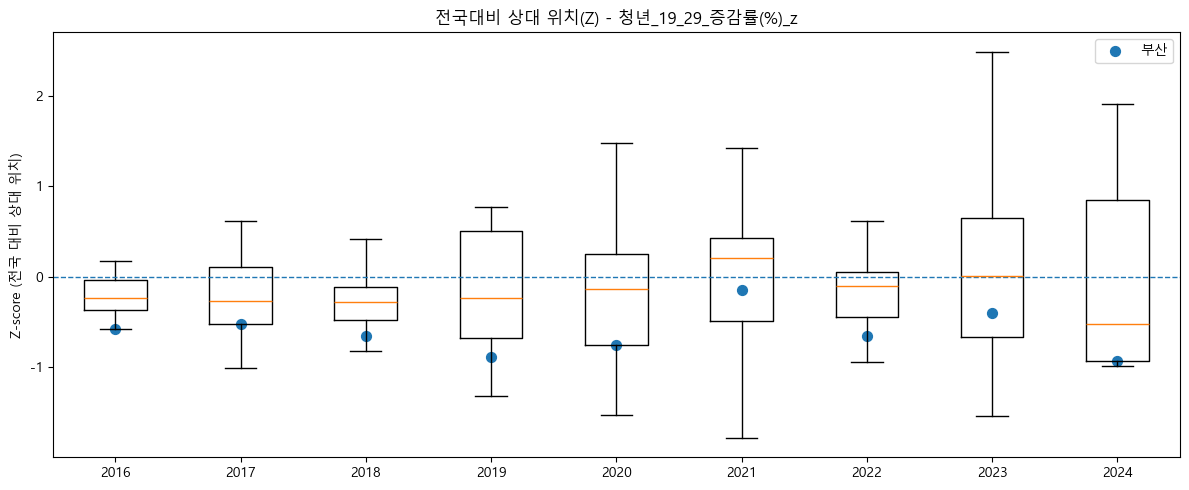

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


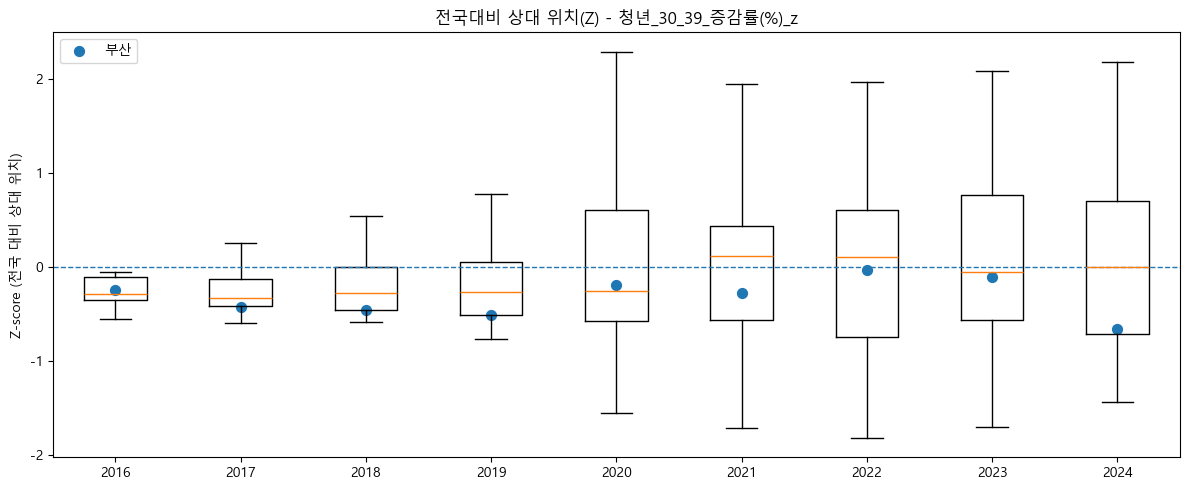

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


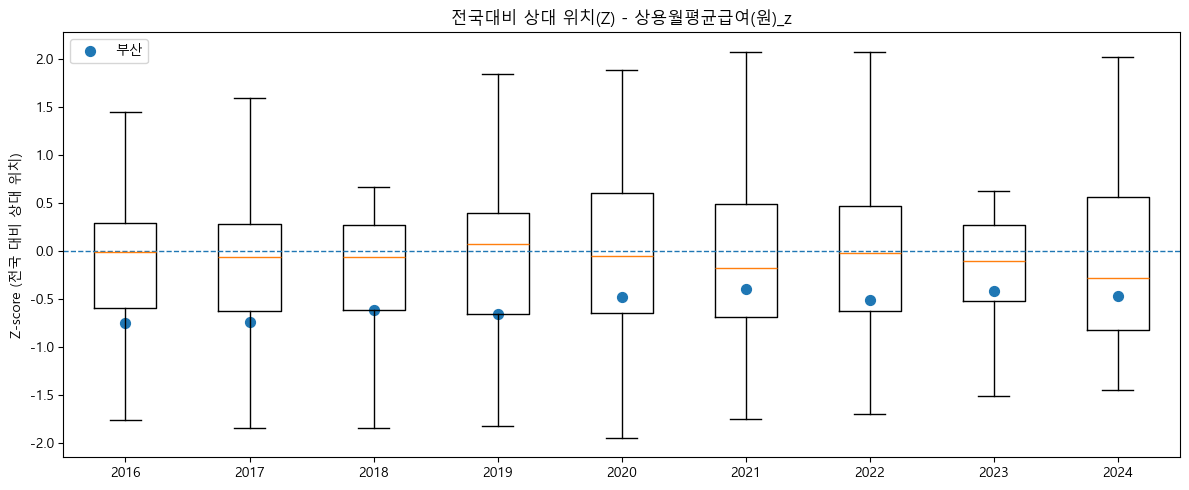

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


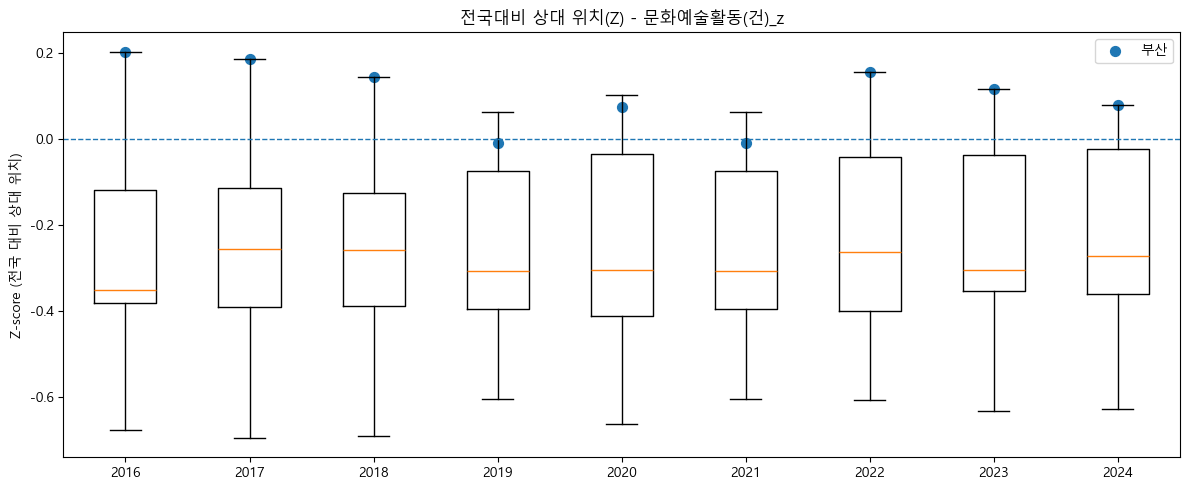

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


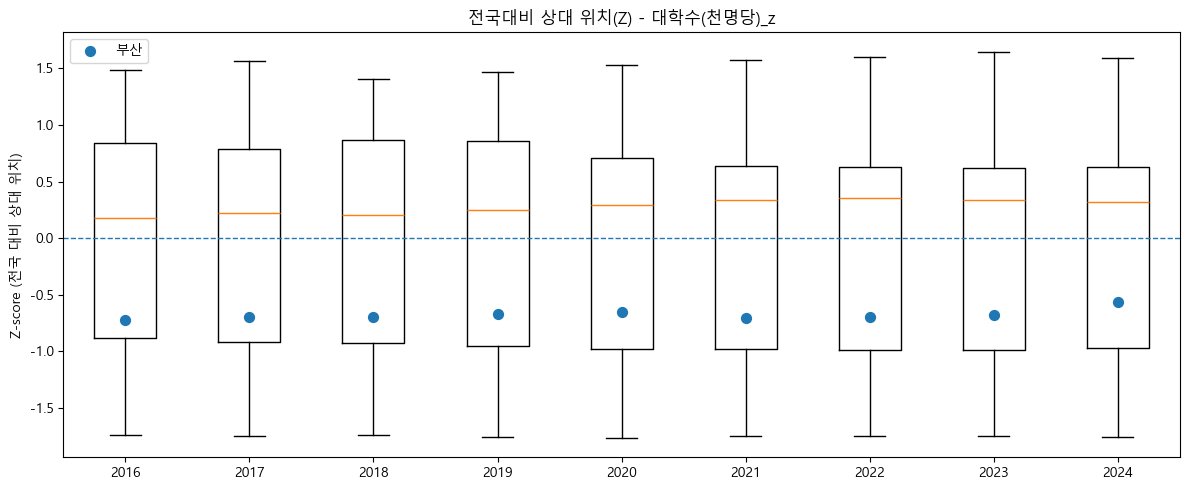

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


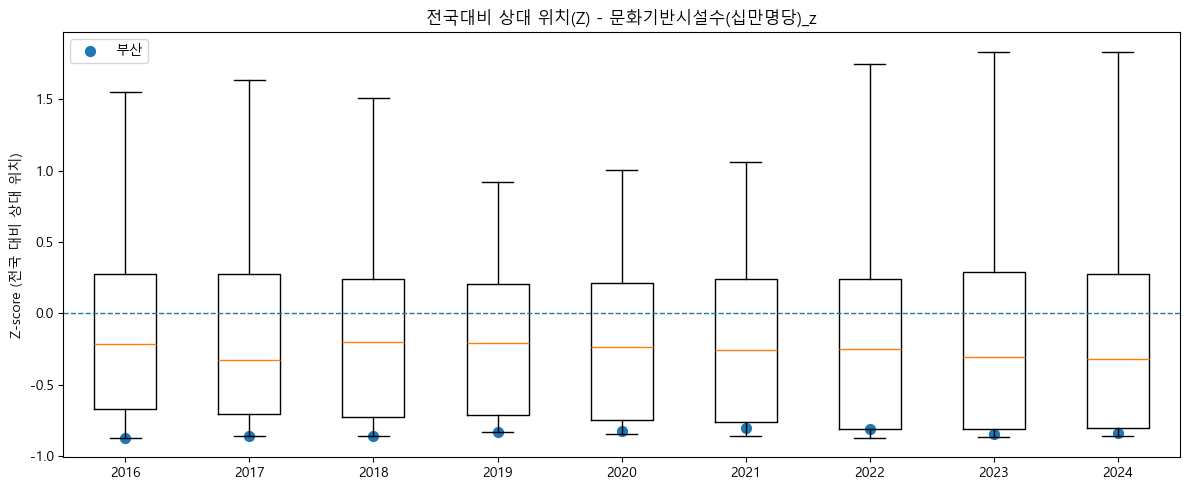

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


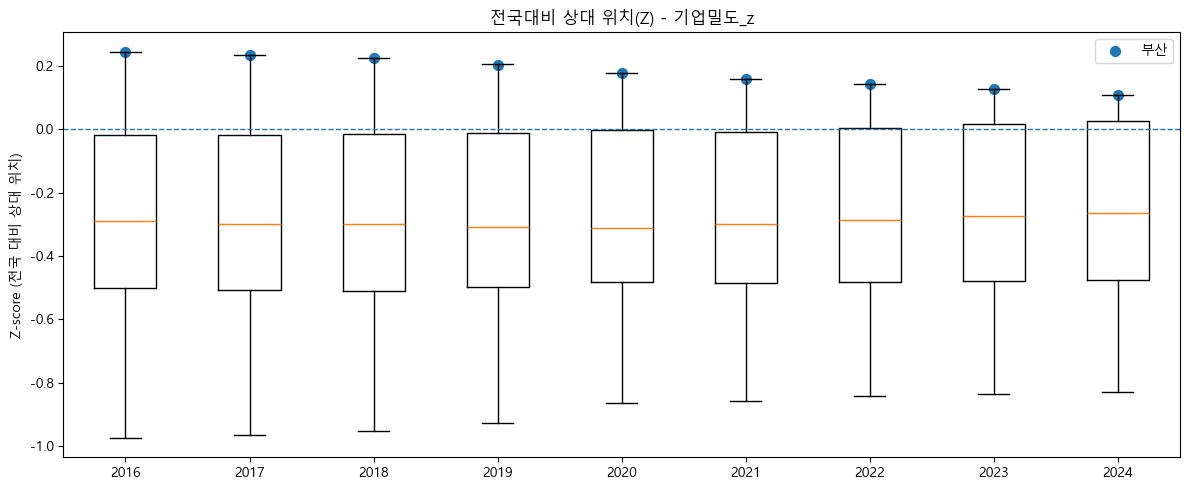

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


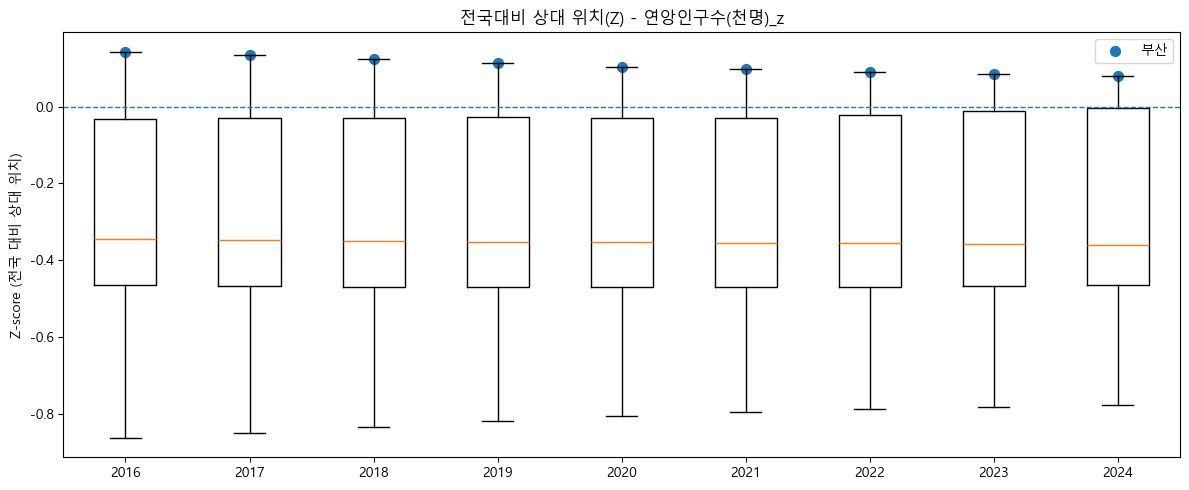

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


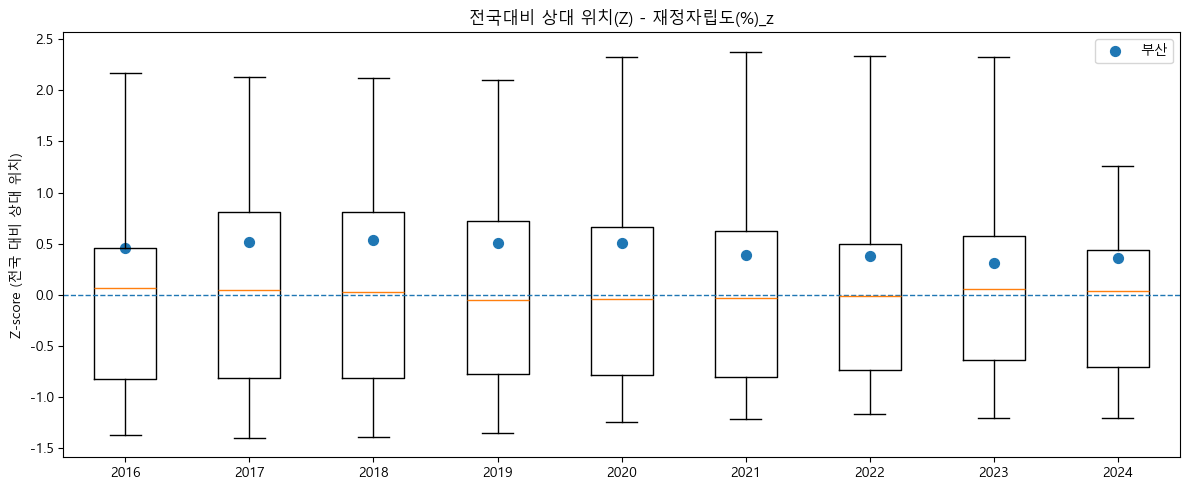

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_18520\922426483.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


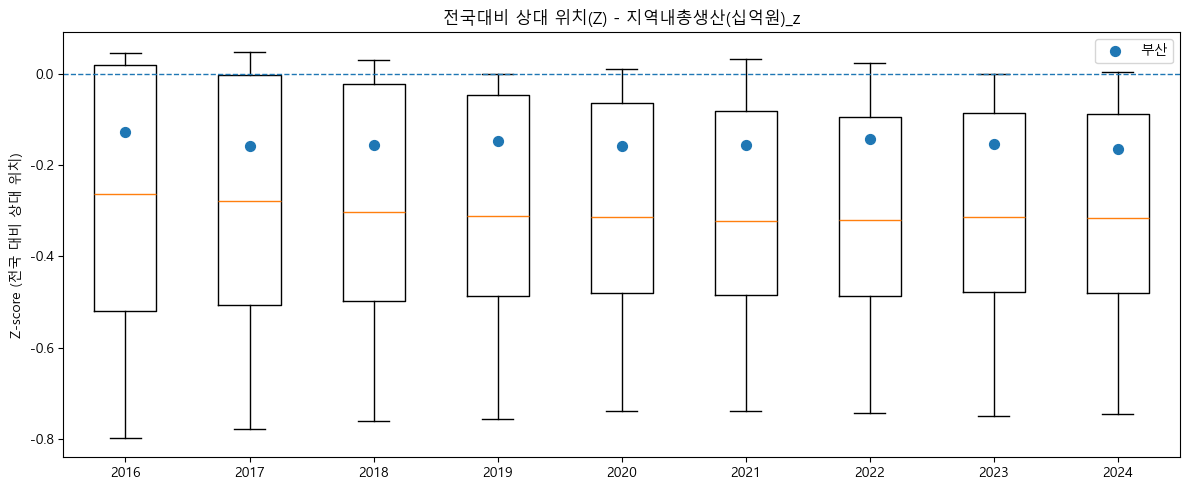

In [46]:
for col in z_cols:   # 예: 8개 특성 z컬럼 리스트
    boxplot_yearly_with_busan_point(
        df_z=tmp_z,
        z_cols=col,
        title=f"전국대비 상대 위치(Z) - {col}"
    )


In [47]:
# import numpy as np
# import matplotlib.pyplot as plt

# z_col = "청년_19_29_증감률(%)_z"

# years = sorted(tmp_z["연도"].dropna().unique())
# data_by_year = [tmp_z.loc[tmp_z["연도"]==y, z_col].dropna().astype(float).values for y in years]

# busan_points = []
# for y in years:
#     s = tmp_z.loc[(tmp_z["연도"]==y) & (tmp_z["행정구역"]=="부산광역시"), z_col]
#     busan_points.append(float(s.iloc[0]) if len(s) else np.nan)

# plt.figure(figsize=(12,5))
# plt.boxplot(data_by_year, labels=years, showfliers=False)
# plt.scatter(np.arange(1, len(years)+1), busan_points, s=50, label="부산")
# plt.axhline(0, linestyle="--", linewidth=1)
# plt.title("연도별 박스플롯 + 부산 점 (Z-score)")
# plt.ylabel("Z-score")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [48]:
# Z-score 히트맵(도시 DNA지도) - 부산 8개 특성 Z히트맵

dna_map = (
    z_cols_busan
    .set_index('연도')[z_cols]
    .T
)

dna_map


연도,2016,2017,2018,2019,2020,2021,2022,2023,2024
청년_19_29_증감률(%)_z,-0.579380,-0.522525,-0.655244,-0.881924,-0.749982,-0.148821,-0.658018,-0.402256,-0.924423
청년_30_39_증감률(%)_z,-0.239824,-0.426332,-0.457192,-0.507070,-0.193108,-0.278071,-0.026412,-0.102928,-0.657936
상용월평균급여(원)_z,-0.752048,-0.743358,-0.616407,-0.654720,-0.485619,-0.394760,-0.511767,-0.416512,-0.473356
문화예술활동(건)_z,0.203951,0.186550,0.145828,-0.007670,0.074376,-0.007670,0.155662,0.116384,0.078923
대학수(천명당)_z,-0.724384,-0.697547,-0.692370,-0.673343,-0.653049,-0.707601,-0.692672,-0.674306,-0.561149
문화기반시설수(십만명당)_z,-0.871036,-0.857878,-0.856537,-0.831291,-0.824099,-0.801185,-0.807214,-0.843869,-0.836980
기업밀도_z,0.244947,0.233573,0.224377,0.202989,0.178028,0.159529,0.143142,0.128063,0.108004
연앙인구수(천명)_z,0.142879,0.133287,0.122626,0.112518,0.104236,0.096783,0.089801,0.084120,0.078339
재정자립도(%)_z,0.453596,0.516095,0.532964,0.505363,0.502001,0.389980,0.374920,0.309353,0.360497
지역내총생산(십억원)_z,-0.127948,-0.157955,-0.155544,-0.146210,-0.158862,-0.155654,-0.141809,-0.152871,-0.165156


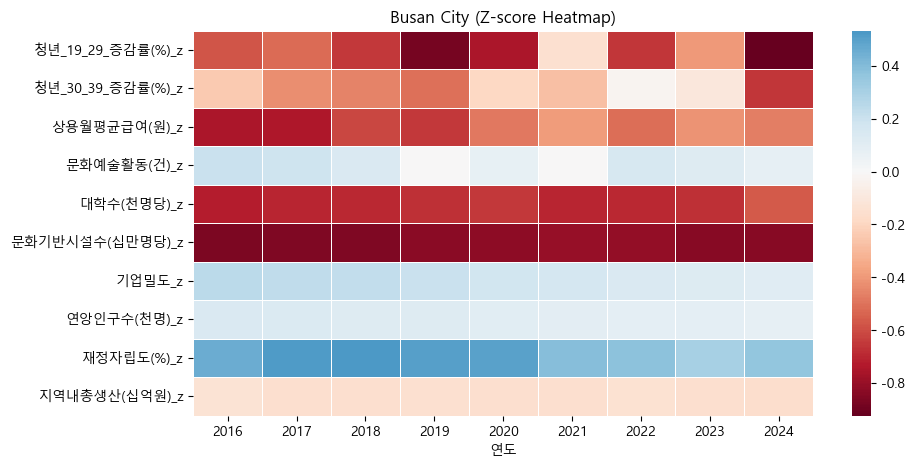

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(
    dna_map,
    cmap='RdBu',     # Z-score용 발산형
    center=0,          # 0 기준
    linewidths=0.5
)
plt.title("Busan City (Z-score Heatmap)")
plt.show()

# 빨강(−): 전국 평균 대비 약함
# 파랑(+): 전국 평균 대비 강함

In [50]:
tmp_z

,연도,행정구역,청년_19_29_증감률(%),청년_30_39_증감률(%),상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,연앙인구수(천명),...,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
0,2016,강원특별자치도,1.149646,-2.070627,3023906.0,1444.0,0.012368,13.734520,351.305988,1536.2750,...,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361
1,2016,경기도,1.820153,-0.773010,3328379.0,3925.0,0.006235,4.028943,2230.077238,12509.4835,...,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738
2,2016,경상남도,-0.054546,-2.108272,3257296.0,1689.0,0.007168,5.764203,652.882347,3348.2515,...,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773
3,2016,경상북도,-0.105801,-2.177146,3326347.0,1035.0,0.014533,7.266690,549.557763,2683.4775,...,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230
4,2016,광주광역시,-0.390397,-3.492136,2994355.0,1284.0,0.012316,3.900020,289.682121,1461.5310,...,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,-5.046648,-0.016089,4034870.0,1438.0,0.010601,13.390429,504.474684,1792.3250,...,-0.518022,0.005958,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644
149,2024,전북특별자치도,-5.533847,-0.308514,3736595.0,1839.0,0.011483,10.794448,537.972610,1741.6360,...,-0.972103,-0.271329,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302
150,2024,제주특별자치도,-5.538364,-0.833774,3501134.0,1053.0,0.005979,18.832645,202.652238,669.0510,...,-0.976313,-0.769400,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959
151,2024,충청남도,-2.439551,0.305802,4680157.0,1832.0,0.011286,9.357610,545.099532,2126.6115,...,1.911852,0.311186,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253


In [51]:
tmp_z.columns

Index(['연도', '행정구역', '청년_19_29_증감률(%)', '청년_30_39_증감률(%)', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '연앙인구수(천명)',
       '재정자립도(%)', '지역내총생산(십억원)', '청년_19_29_증감률(%)_z', '청년_30_39_증감률(%)_z',
       '상용월평균급여(원)_z', '문화예술활동(건)_z', '대학수(천명당)_z', '문화기반시설수(십만명당)_z',
       '기업밀도_z', '연앙인구수(천명)_z', '재정자립도(%)_z', '지역내총생산(십억원)_z'],
      dtype='object')

In [52]:
# # 레이더차트 부산 vs 전국 평균(2024년)

# import numpy as np
# import matplotlib.pyplot as plt

# def radar_busan_vs_national(tmp_z, year, feature_z_cols,
#                            year_col="연도", region_col="행정구역",
#                            busan_name="부산광역시",
#                            national_mode="mean", title=None, fill_alpha=0.20):

#     # 컬럼 체크
#     need_cols = [year_col, region_col] + list(feature_z_cols)
#     missing = [c for c in need_cols if c not in tmp_z.columns]
#     if missing:
#         raise ValueError(f"tmp_z에 없는 컬럼: {missing}")

#     # year 자동 선택
#     if year is None:
#         year = int(tmp_z[year_col].max())

#     df_y = tmp_z[tmp_z[year_col] == year].copy()
#     if df_y.empty:
#         raise ValueError(f"{year}년 데이터가 없습니다.")

#     busan_row = df_y[df_y[region_col] == busan_name]
#     if busan_row.empty:
#         cand = sorted(tmp_z[region_col].astype(str).unique().tolist())
#         raise ValueError(f"{year}년 '{busan_name}' 없음. 지역명 후보(일부): {cand[:30]}")

#     busan_vals = busan_row[feature_z_cols].iloc[0].astype(float).values

#     if national_mode == "mean":
#         national_vals = df_y[feature_z_cols].mean().astype(float).values
#         national_label = "전국 평균"
#     elif national_mode == "zero":
#         national_vals = np.zeros(len(feature_z_cols))
#         national_label = "전국 평균(0선)"
#     else:
#         raise ValueError("national_mode는 'mean' 또는 'zero'만 가능합니다.")

#     labels = [c.replace("_z", "") for c in feature_z_cols]
#     N = len(labels)

#     angles = np.linspace(0, 2*np.pi, N, endpoint=False)
#     angles_closed = np.r_[angles, angles[0]]

#     busan_closed = np.r_[busan_vals, busan_vals[0]]
#     national_closed = np.r_[national_vals, national_vals[0]]

#     plt.figure(figsize=(8, 6))
#     ax = plt.subplot(111, polar=True)

#     ax.plot(angles_closed, busan_closed, linewidth=2, label="부산")
#     ax.fill(angles_closed, busan_closed, alpha=fill_alpha)
#     ax.plot(angles_closed, national_closed, linewidth=2, linestyle="--", label=national_label)

#     ax.set_xticks(angles)
#     ax.set_xticklabels(labels, fontsize=9)

#     lim = np.nanmax(np.abs(np.r_[busan_vals, national_vals]))
#     lim = 1.0 if (not np.isfinite(lim) or lim < 1) else float(np.ceil(lim * 2) / 2)
#     ax.set_ylim(-lim, lim)

#     ax.set_title(title if title else f"부산 vs {national_label} 레이더(Z) - {year}년", pad=20)
#     ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

#     plt.show()


# # ===== 실행 예시 =====
# feature_z_cols = [
#     "청년_19_29_증감률(%)_z",
#     "청년_30_39_증감률(%)_z",
#     "상용월평균급여(원)_z",
#     "문화예술활동(건)_z",
#     "대학수(천명당)_z",
#     "문화기반시설수(십만명당)_z",
#     "기업밀도_z",
#     "지역내총생산(십억원)_z"
# ]

# radar_busan_vs_national(tmp_z, year=2024, feature_z_cols=feature_z_cols, national_mode="mean")


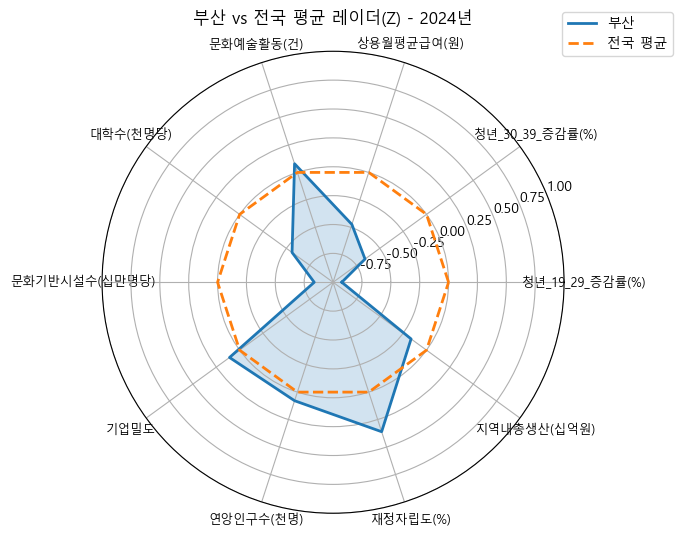

In [53]:
# 레이더차트 부산 vs 전국 평균(2024년)



def radar_busan_vs_national(tmp_z, year, z_cols,
                           year_col="연도", region_col="행정구역",
                           busan_name="부산광역시",
                           national_mode="mean", title=None, fill_alpha=0.20):

    # 컬럼 체크
    need_cols = [year_col, region_col] + list(z_cols)
    missing = [c for c in need_cols if c not in tmp_z.columns]
    if missing:
        raise ValueError(f"tmp_z에 없는 컬럼: {missing}")

    # year 자동 선택
    if year is None:
        year = int(tmp_z[year_col]. max())

    df_y = tmp_z[tmp_z[year_col] == year].copy()
    if df_y.empty:
        raise ValueError(f"{year}년 데이터가 없습니다.")

    busan_row = df_y[df_y[region_col] == busan_name]
    if busan_row.empty:
        cand = sorted(tmp_z[region_col].astype(str).unique().tolist())
        raise ValueError(f"{year}년 '{busan_name}' 없음. 지역명 후보(일부): {cand[:30]}")

    busan_vals = busan_row[z_cols].iloc[0].astype(float).values

    if national_mode == "mean":
        national_vals = df_y[z_cols].mean().astype(float).values
        national_label = "전국 평균"
    elif national_mode == "zero":
        national_vals = np.zeros(len(z_cols))
        national_label = "전국 평균(0선)"
    else:
        raise ValueError("national_mode는 'mean' 또는 'zero'만 가능합니다.")

    labels = [c.replace("_z", "") for c in z_cols]
    N = len(labels)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    busan_closed = np.r_[busan_vals, busan_vals[0]]
    national_closed = np.r_[national_vals, national_vals[0]]

    plt.figure(figsize=(8, 6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles_closed, busan_closed, linewidth=2, label="부산")
    ax.fill(angles_closed, busan_closed, alpha=fill_alpha)
    ax.plot(angles_closed, national_closed, linewidth=2, linestyle="--", label=national_label)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9) 

    lim = np.nanmax(np.abs(np.r_[busan_vals, national_vals]))
    lim = 1.0 if (not np.isfinite(lim) or lim < 1) else float(np.ceil(lim * 2) / 2)
    ax.set_ylim(-lim, lim)

    ax.set_title(title if title else f"부산 vs {national_label} 레이더(Z) - {year}년", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

    plt.show()


radar_busan_vs_national(tmp_z, year=2024, z_cols=z_cols, national_mode="mean")


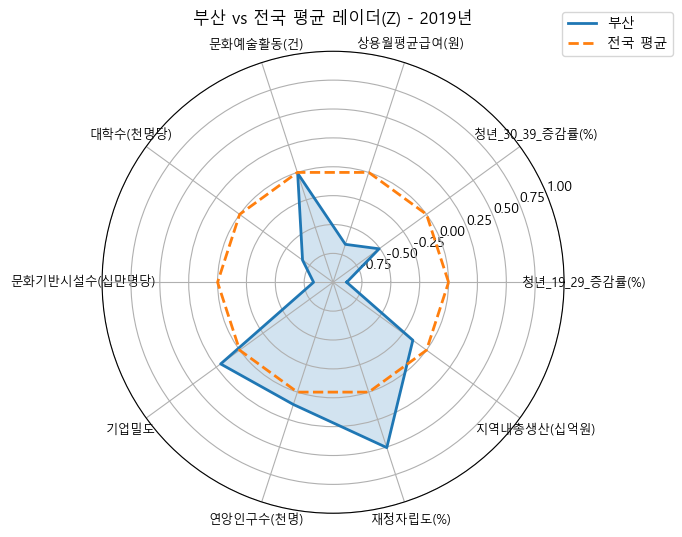

In [54]:
radar_busan_vs_national(tmp_z, year=2019, z_cols=z_cols, national_mode="mean")

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def radar_busan_two_years(
    tmp_z,
    year1,
    year2,
    feature_z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    title=None,
    fill_alpha=0.12
):
    # 0) 컬럼 체크
    need_cols = [year_col, region_col] + list(feature_z_cols)
    missing = [c for c in need_cols if c not in tmp_z.columns]
    if missing:
        raise ValueError(f"tmp_z에 없는 컬럼: {missing}")

    def get_vals(y):
        row = tmp_z[(tmp_z[year_col]==y) & (tmp_z[region_col]==busan_name)]
        if row.empty:
            raise ValueError(f"{y}년 {busan_name} 데이터가 없습니다.")
        return row[feature_z_cols].iloc[0].astype(float).values

    v1 = get_vals(year1)
    v2 = get_vals(year2)

    labels = [c.replace("_z","") for c in feature_z_cols]
    N = len(labels)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    v1_closed = np.r_[v1, v1[0]]
    v2_closed = np.r_[v2, v2[0]]

    plt.figure(figsize=(8, 6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles_closed, v1_closed, linewidth=2, label=f"부산 {year1}")
    ax.fill(angles_closed, v1_closed, alpha=fill_alpha)

    ax.plot(angles_closed, v2_closed, linewidth=2, linestyle="--", label=f"부산 {year2}")
    ax.fill(angles_closed, v2_closed, alpha=fill_alpha)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)

    lim = np.nanmax(np.abs(np.r_[v1, v2]))
    lim = 1.0 if (not np.isfinite(lim) or lim < 1) else float(np.ceil(lim * 2) / 2)
    ax.set_ylim(-lim, lim)

    ax.set_title(title if title else f"부산 도시 DNA 레이더(Z) - {year1} vs {year2}", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1))

    plt.show()


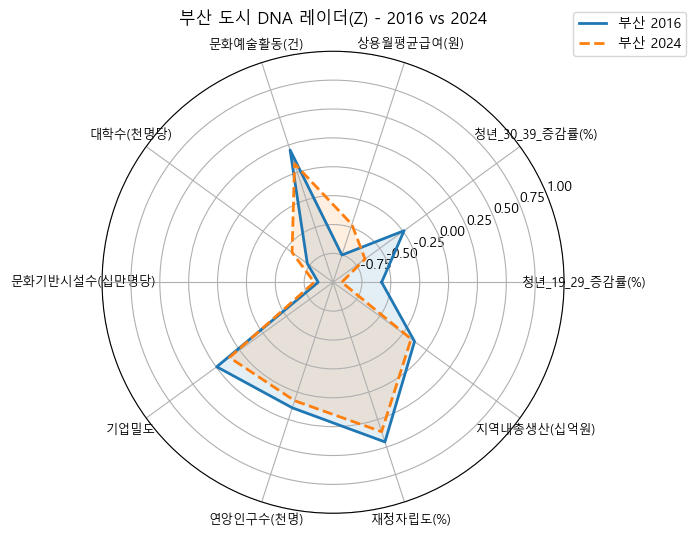

In [56]:
radar_busan_two_years(
    tmp_z=tmp_z,
    year1=2016,
    year2=2024,
    feature_z_cols=z_cols
)

In [ ]:
# 레이더차트 다시 그리기!! (중복 함수 제거)
# 0) 공용 유틸 
def _check_cols(df, cols, df_name="df"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name}에 없는 컬럼: {missing}")

def _get_region_vals(df, *, year, z_cols, year_col, region_col, region_name):
    sub = df[df[year_col] == year]
    if sub.empty:
        raise ValueError(f"{year}년 데이터가 없습니다.")
    row = sub[sub[region_col] == region_name]
    if row.empty:
        cand = sorted(df[region_col].astype(str).unique().tolist())
        raise ValueError(f"{year}년 '{region_name}' 없음. 지역명 후보(일부): {cand[:30]}")
    return row[z_cols].iloc[0].astype(float).values

def _get_national_vals(df, *, year, z_cols, year_col, mode):
    sub = df[df[year_col] == year]
    if sub.empty:
        raise ValueError(f"{year}년 데이터가 없습니다.")
    if mode == "mean":
        return sub[z_cols].mean().astype(float).values, "전국 평균"
    if mode == "zero":
        return np.zeros(len(z_cols)), "전국 평균(0선)"
    raise ValueError("mode는 'mean' 또는 'zero'만 가능합니다.")

def _radar_plot(series_dict, *, z_cols, title, fill_alpha=0.15, figsize=(8, 6), legend_anchor=(1.25, 1.1)):
    """
    series_dict: {label: np.array(values)}  # 길이 = len(z_cols)
    """
    labels = [c.replace("_z", "") for c in z_cols]
    N = len(labels)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    # 축 범위(공용): 모든 시리즈 값의 절대값 기준
    all_vals = np.concatenate([v for v in series_dict.values()])
    lim = np.nanmax(np.abs(all_vals))
    lim = 1.0 if (not np.isfinite(lim) or lim < 1) else float(np.ceil(lim * 2) / 2)

    plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    # 선 스타일: 첫 시리즈 실선, 이후 점선
    for i, (label, vals) in enumerate(series_dict.items()):
        vals_closed = np.r_[vals, vals[0]]
        linestyle = "-" if i == 0 else "--"
        ax.plot(angles_closed, vals_closed, linewidth=2, linestyle=linestyle, label=label)
        ax.fill(angles_closed, vals_closed, alpha=fill_alpha)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(-lim, lim)
    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=legend_anchor)
    plt.show()



# 1) 부산 vs 전국평균 (연도별)

def radar_busan_vs_national(
    tmp_z, year, z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    national_mode="mean",
    title=None,
    fill_alpha=0.20
):
    _check_cols(tmp_z, [year_col, region_col] + list(z_cols), "tmp_z")

    if year is None:
        year = int(tmp_z[year_col].max())

    busan_vals = _get_region_vals(
        tmp_z, year=year, z_cols=z_cols,
        year_col=year_col, region_col=region_col, region_name=busan_name
    )
    national_vals, national_label = _get_national_vals(
        tmp_z, year=year, z_cols=z_cols, year_col=year_col, mode=national_mode
    )

    series = {
        "부산": busan_vals,
        national_label: national_vals
    }
    _radar_plot(
        series, z_cols=z_cols,
        title=title if title else f"부산 vs {national_label} 레이더(Z) - {year}년",
        fill_alpha=fill_alpha
    )


# 2) 부산 연도 vs 연도

def radar_busan_two_years(
    tmp_z, year1, year2, z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    title=None,
    fill_alpha=0.12
):
    _check_cols(tmp_z, [year_col, region_col] + list(z_cols), "tmp_z")

    v1 = _get_region_vals(
        tmp_z, year=year1, z_cols=z_cols,
        year_col=year_col, region_col=region_col, region_name=busan_name
    )
    v2 = _get_region_vals(
        tmp_z, year=year2, z_cols=z_cols,
        year_col=year_col, region_col=region_col, region_name=busan_name
    )

    series = {
        f"부산 {year1}": v1,
        f"부산 {year2}": v2
    }
    _radar_plot(
        series, z_cols=z_cols,
        title=title if title else f"부산 도시 DNA 레이더(Z) - {year1} vs {year2}",
        fill_alpha=fill_alpha,
        legend_anchor=(1.28, 1.1)
    )

# 레이더 차트 그리기
# 부산 vs 전국 평균(2024년)
radar_busan_vs_national(tmp_z, year=2024, z_cols=z_cols, national_mode="mean")
# 부산 vs 전국 평균(2016년)
radar_busan_vs_national(tmp_z, year=2016, z_cols=z_cols, national_mode="mean")
# 연도별 부산비교(2016년 vs 2024년)
radar_busan_two_years(tmp_z, year1=2016, year2=2024, z_cols=z_cols)
